In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Cleaned Dataset sheet1.csv')

In [4]:
df.head()

,Unnamed: 0,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [72]:
df.shape

(1200, 14)

In [5]:
df.describe()

,Unnamed: 0,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,599.500000,2.945833,356.412750,5.485000,1053.968300
std,346.554469,1.407557,197.177146,2.281983,819.856558
min,0.000000,1.000000,11.390000,1.000000,11.390000
25%,299.750000,2.000000,186.062500,4.000000,410.520000
50%,599.500000,3.000000,364.210000,5.000000,823.615000
75%,899.250000,4.000000,521.570000,7.000000,1578.475000
max,1199.000000,5.000000,699.930000,10.000000,3456.400000


In [6]:
df = df.drop("Unnamed: 0", axis=1)

In [7]:
df.head(2)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.7


## Univariate Analysis

<Axes: xlabel='TotalPrice', ylabel='Count'>

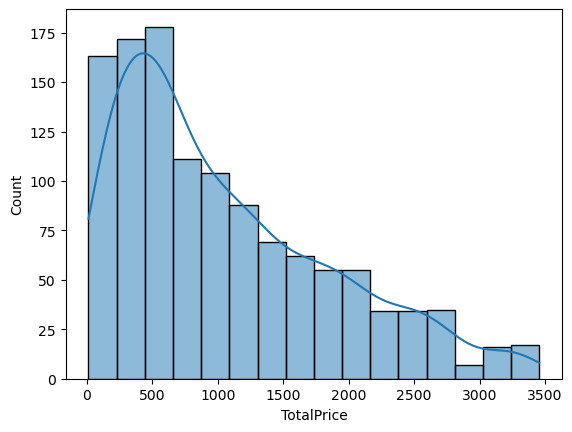

In [ ]:
#Total Price
sns.histplot(df['TotalPrice'], kde=True)

<Axes: xlabel='UnitPrice', ylabel='Count'>

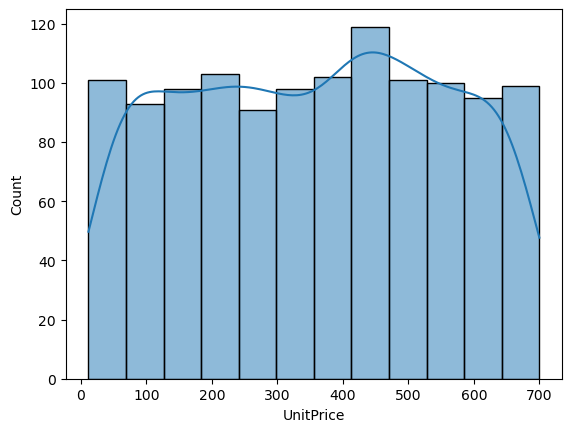

In [ ]:
# Unit Price
sns.histplot(df['UnitPrice'], kde=True)

<Axes: xlabel='Quantity', ylabel='Count'>

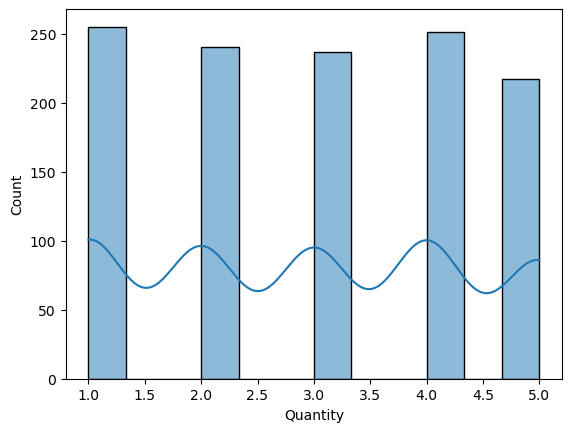

In [ ]:
#Quantity
sns.histplot(df['Quantity'], kde=True)

<Axes: xlabel='ItemsInCart', ylabel='Count'>

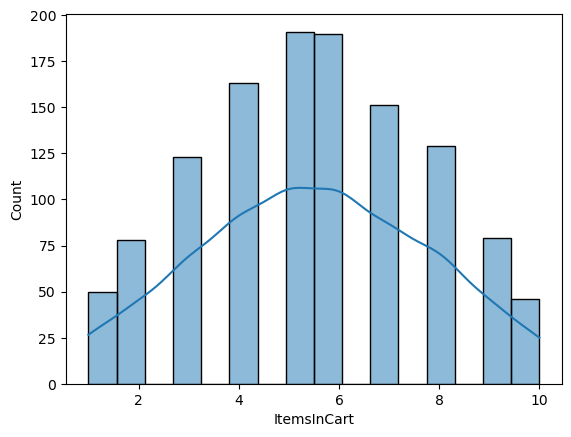

In [ ]:
#ItemsInCart
sns.histplot(df['ItemsInCart'], kde=True)

## Statistics


In [8]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', "TotalPrice"]].mean()

Quantity          2.945833
UnitPrice       356.412750
ItemsInCart       5.485000
TotalPrice     1053.968300
dtype: float64

In [9]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', "TotalPrice"]].median()

Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64

## The Five Number Summary

In [10]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [ ]:

df[['Quantity', 'UnitPrice', 'ItemsInCart', "TotalPrice"]].min()


Quantity        1.00
UnitPrice      11.39
ItemsInCart     1.00
TotalPrice     11.39
dtype: float64

In [12]:
df[['Quantity', 'UnitPrice', 'ItemsInCart', "TotalPrice"]].max()
total = df[['Quantity', 'UnitPrice', 'ItemsInCart', "TotalPrice"]].quantile([.25, .50, .75])

In [ ]:
total

,Quantity,UnitPrice,ItemsInCart,TotalPrice
0.25,2.0,186.0625,4.0,410.520
0.50,3.0,364.2100,5.0,823.615
0.75,4.0,521.5700,7.0,1578.475


## Identifying Outliers


In [34]:
quantity_iqr = total['Quantity'].iloc[2]-total['Quantity'].iloc[0]
quantity_iqr
quantity_lowest_point = total['Quantity'].iloc[0] -1.5*quantity_iqr
quantity_lowest_point
quantity_highest_point = total['Quantity'].iloc[0] + 1.5*quantity_iqr
quantity_highest_point

np.float64(5.0)

In [36]:
df[(df['Quantity']<quantity_lowest_point) | (df['Quantity']> quantity_highest_point)]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


In [41]:
unitprice_iqr = total['UnitPrice'].iloc[2]-total['UnitPrice'].iloc[0]
unitprice_lowest_point = total['UnitPrice'].iloc[0] - 1.5*unitprice_iqr
unitprice_highest_point = total['UnitPrice'].iloc[0]+ 1.5*unitprice_iqr
unitprice_highest_point

np.float64(689.3237499999999)

In [116]:
unitprice_outlier = df[(df['UnitPrice']<unitprice_lowest_point) | (df['UnitPrice']>unitprice_highest_point)]
unitprice_outlier['UnitPrice'].count()

np.int64(18)

In [ ]:
ItemsInCart_iqr = total['ItemsInCart'].iloc[2]-total['ItemsInCart'].iloc[0]
ItemsInCart_lowest_point = total['ItemsInCart'].iloc[0] - 1.5*ItemsInCart_iqr
ItemsInCart_highest_point = total['ItemsInCart'].iloc[0]+ 1.5*ItemsInCart_iqr
ItemsInCart_highest_point

np.float64(8.5)

In [44]:
df[(df['ItemsInCart']<ItemsInCart_lowest_point) | (df['ItemsInCart']>ItemsInCart_highest_point)]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
10,ORD200010,2023-12-29,C43443,Tablet,5,625.97,333 Main St,Credit Card,Returned,TRK98859248,9,WINTER15,Instagram,3129.85
19,ORD200019,2023-01-23,C14552,Monitor,5,224.00,273 Main St,Cash,Returned,TRK59101365,9,SAVE10,Google,1120.00
20,ORD200020,2023-05-08,C54829,Chair,5,62.51,587 Main St,Cash,Pending,TRK16718651,9,WINTER15,Instagram,312.55
32,ORD200032,2023-05-01,C12388,Tablet,5,536.72,830 Main St,Cash,Delivered,TRK99261395,10,NO COUPON,Email,2683.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1064,ORD201064,2025-02-12,C32121,Laptop,4,198.81,654 Main St,Cash,Returned,TRK96074264,9,FREESHIP,Referral,795.24
1093,ORD201093,2023-06-09,C86773,Phone,4,197.36,557 Main St,Gift Card,Returned,TRK22612240,9,FREESHIP,Instagram,789.44
1111,ORD201111,2023-05-06,C24047,Monitor,4,234.45,362 Main St,Online,Cancelled,TRK91338580,9,FREESHIP,Instagram,937.80
1144,ORD201144,2023-02-16,C88463,Desk,5,507.94,292 Main St,Online,Cancelled,TRK88749996,9,NO COUPON,Facebook,2539.70


In [45]:
TotalPrice_iqr = total['TotalPrice'].iloc[2]-total['TotalPrice'].iloc[0]
TotalPrice_iqr
TotalPrice_lowest_point = total['TotalPrice'].iloc[0] -1.5*TotalPrice_iqr
TotalPrice_lowest_point
TotalPrice_highest_point = total['TotalPrice'].iloc[0] + 1.5*TotalPrice_iqr
TotalPrice_highest_point

np.float64(2162.4525)

In [46]:
df[(df['TotalPrice']<TotalPrice_lowest_point) | (df['TotalPrice']>TotalPrice_highest_point)]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
10,ORD200010,2023-12-29,C43443,Tablet,5,625.97,333 Main St,Credit Card,Returned,TRK98859248,9,WINTER15,Instagram,3129.85
32,ORD200032,2023-05-01,C12388,Tablet,5,536.72,830 Main St,Cash,Delivered,TRK99261395,10,NO COUPON,Email,2683.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1144,ORD201144,2023-02-16,C88463,Desk,5,507.94,292 Main St,Online,Cancelled,TRK88749996,9,NO COUPON,Facebook,2539.70
1153,ORD201153,2024-12-16,C98317,Monitor,4,696.71,276 Main St,Debit Card,Shipped,TRK37172138,4,NO COUPON,Instagram,2786.84
1156,ORD201156,2023-07-19,C20512,Laptop,4,690.78,980 Main St,Credit Card,Shipped,TRK98234737,9,NO COUPON,Referral,2763.12
1179,ORD201179,2023-01-08,C84630,Laptop,5,518.55,907 Main St,Credit Card,Cancelled,TRK48054997,6,WINTER15,Instagram,2592.75


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [58]:
numericalcols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

<Axes: xlabel='Quantity'>

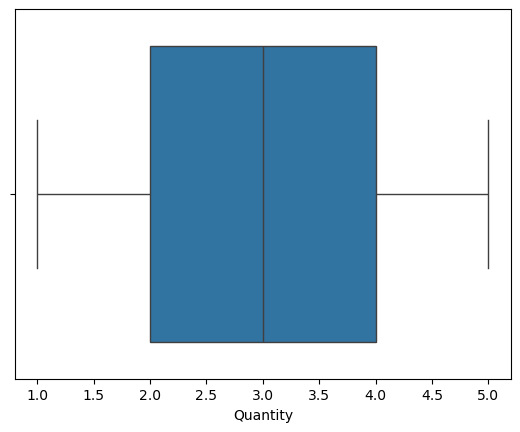

In [67]:
sns.boxplot(x=df['Quantity'])

<Axes: xlabel='UnitPrice'>

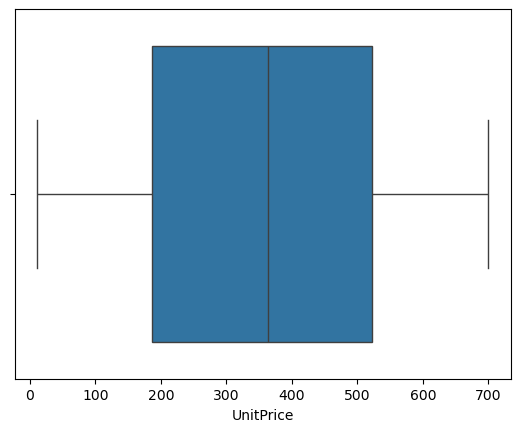

In [68]:
sns.boxplot(x=df['UnitPrice'])

<Axes: xlabel='ItemsInCart'>

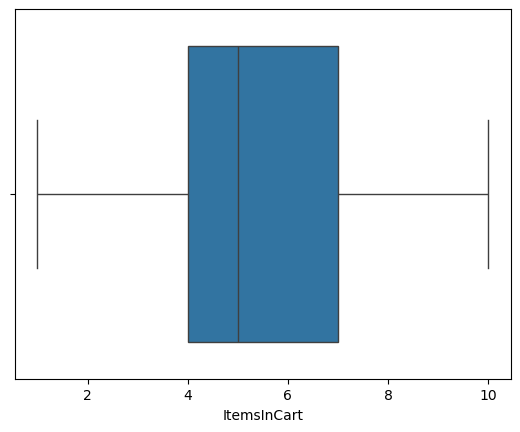

In [66]:
sns.boxplot(x=df['ItemsInCart'])

<Axes: xlabel='TotalPrice'>

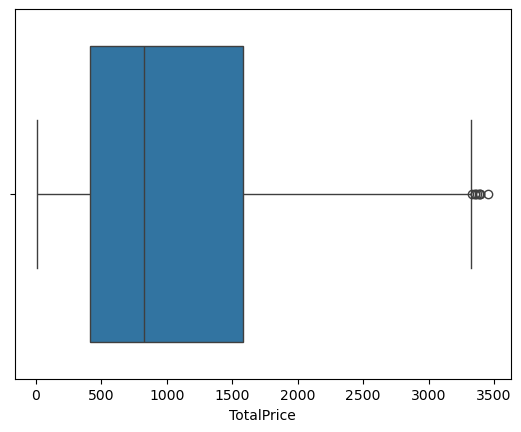

In [70]:
sns.boxplot(x=df['TotalPrice'])

<Axes: >

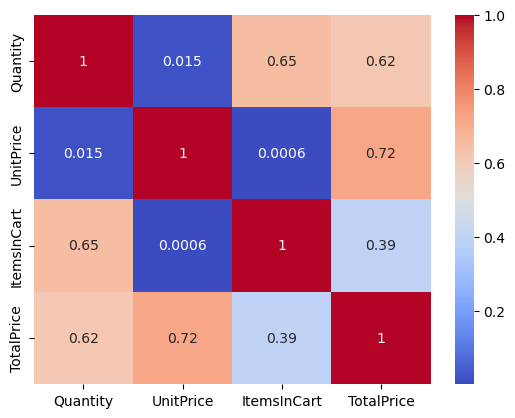

In [117]:
sns.heatmap(df[numericalcols].corr(), annot=True, cmap='coolwarm')

## Data analysis

In [73]:
df.head(2)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.7


In [ ]:
# frequently purchased product
df.groupby('Product')['ItemsInCart'].count().sort_values(ascending=False)

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: ItemsInCart, dtype: int64

In [79]:
# Revenue generated by each product 
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

In [91]:
paymentmethod = df.groupby('PaymentMethod')['TotalPrice'].count().sort_values(ascending=False)
paymentmethod

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: TotalPrice, dtype: int64

[]

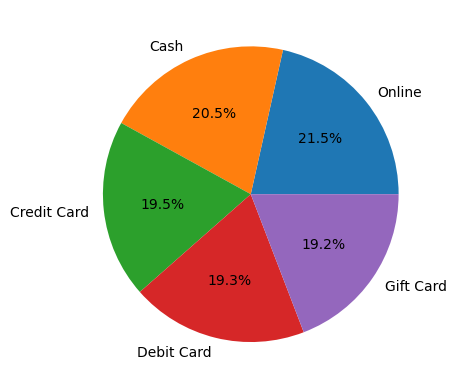

In [98]:
labels = ['Online', 'Cash', 'Credit Card', 'Debit Card', 'Gift Card']
plt.pie(paymentmethod, labels=labels, autopct="%1.1f%%")
plt.plot()

In [119]:
## Highest revenue generating payment methond
df.groupby('PaymentMethod')['TotalPrice'].sum().sort_values(ascending=False)

PaymentMethod
Credit Card    263847.63
Online         262442.94
Cash           259786.29
Gift Card      246323.92
Debit Card     232361.18
Name: TotalPrice, dtype: float64

In [99]:
df.head(2)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.7


In [101]:
df.groupby('ReferralSource')['CustomerID'].count().sort_values(ascending=False)

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: CustomerID, dtype: int64

In [102]:
df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

In [111]:
order_counts = df['OrderStatus'].value_counts()
order_counts

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

[]

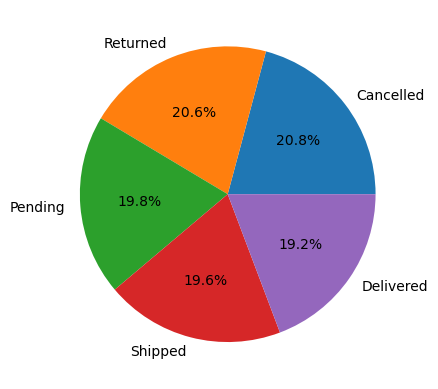

In [113]:
labels = ['Cancelled', "Returned", "Pending", "Shipped", "Delivered"]
plt.pie(order_counts, labels=labels, autopct="%1.1f%%")
plt.plot()